[CNN_Cucarron] dx shape=(256, 256), dy shape=(256, 256), dx min/max=(-0.1422,0.1373), dy min/max=(-0.1523,0.143)
[UMPA_Cucarron] dx shape=(251, 251), dy shape=(251, 251), dx min/max=(-1.484,1.818), dy min/max=(-1.515,1.527)
vmin=-0.18, vmax=0.18


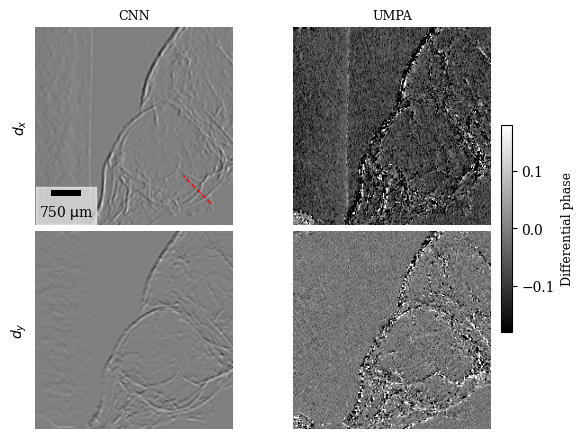

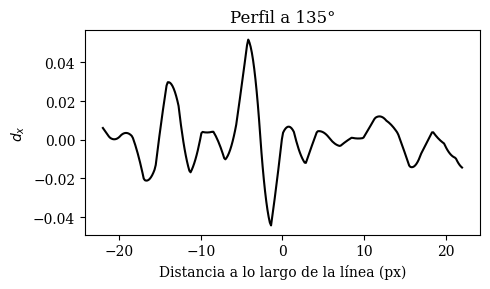

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
from scipy.ndimage import map_coordinates

plt.rcParams['font.family'] = 'serif'

# ---------------------------------------------------------------
# CARGA DE DATOS (SIN CROP)
# ---------------------------------------------------------------
folder_names = ["CNN_Cucarron", "UMPA_Cucarron"]  # ajusta a tus carpetas reales
input_folder = "/home/c.tibambre/FS_Study/"
dx_name = "dx.txt"
dy_name = "dy.txt"
column_titles = ["CNN", "UMPA"]

dx_images = []
dy_images = []

for folder in folder_names:
    dx = np.loadtxt(input_folder + folder + "/" + dx_name)
    dy = np.loadtxt(input_folder + folder + "/" + dy_name)
    print(f"[{folder}] dx shape={dx.shape}, dy shape={dy.shape}, "
          f"dx min/max=({dx.min():.4g},{dx.max():.4g}), "
          f"dy min/max=({dy.min():.4g},{dy.max():.4g})")

    is_cnn = "CNN" in folder  # la CNN no se multiplica por -1 (convención de signo)
    if not is_cnn:
        dx = dx * -1
        dy = dy * -1

    dx_images.append(dx)
    dy_images.append(dy)
crop_slice = (slice(15, 235), slice(15, 235))  # ajusta a lo que necesites

dx_images = [img[crop_slice] for img in dx_images]
dy_images = [img[crop_slice] for img in dy_images]    

# ---------------------------------------------------------------
# VMIN / VMAX COMPARTIDO (sobre datos crudos, sin normalizar ni recortar)
# ---------------------------------------------------------------
all_vals = np.concatenate([img.ravel() for img in dx_images + dy_images])
vmax = 0.18#np.percentile(np.abs(all_vals), 99)

if vmax == 0 or not np.isfinite(vmax):
    raise ValueError(f"vmax calculado = {vmax}. Revisa que los .txt se hayan cargado bien.")

vmin = -vmax
print(f"vmin={vmin:.4g}, vmax={vmax:.4g}")


# ---------------------------------------------------------------
# FUNCIÓN: PERFIL EN DIRECCIÓN ARBITRARIA
# ---------------------------------------------------------------
def extract_profile_arbitrary(img, center, angle_deg, length, num_points=300):
    """
    Extrae un perfil de intensidad a lo largo de una línea recta en
    CUALQUIER dirección sobre una imagen 2D, mediante interpolación.

    Parámetros
    ----------
    img : ndarray (H, W)
    center : tuple (fila, columna)
    angle_deg : float
        Ángulo respecto al eje horizontal, sentido antihorario.
    length : float
        Longitud total de la línea, en píxeles.
    num_points : int

    Retorna
    -------
    distances : ndarray (centrada en 0)
    values : ndarray (valores interpolados de la imagen)
    p0, p1 : tuple (x, y)
        Extremos de la línea, para dibujarla con ax.plot([x0,x1],[y0,y1],...)
    """
    row_c, col_c = center
    theta = np.deg2rad(angle_deg)

    distances = np.linspace(-length / 2, length / 2, num_points)
    x_coords = col_c + distances * np.cos(theta)
    y_coords = row_c - distances * np.sin(theta)  # fila crece hacia abajo

    values = map_coordinates(img, [y_coords, x_coords], order=1, mode='nearest')

    p0 = (x_coords[0], y_coords[0])
    p1 = (x_coords[-1], y_coords[-1])
    return distances, values, p0, p1


# ---------------------------------------------------------------
# GRAFICA: 2x2 (dx/dy x UMPA/CNN), sin crop
# ---------------------------------------------------------------
n_cols = len(folder_names)

fig, axes = plt.subplots(
    2, n_cols,
    figsize=(6.0, 4.2),
    constrained_layout=True
)
fig.get_layout_engine().set(w_pad=0.0, h_pad=0.0, wspace=0.0, hspace=0.03)

im_dx = None
for i in range(n_cols):
    ax_dx = axes[0, i]
    im_dx = ax_dx.imshow(dx_images[i], cmap='gray', vmin=vmin, vmax=vmax)
    ax_dx.set_title(column_titles[i], fontsize=9)
    ax_dx.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax_dx.spines.values():
        spine.set_visible(False)

    ax_dy = axes[1, i]
    ax_dy.imshow(dy_images[i], cmap='gray', vmin=vmin, vmax=vmax)
    ax_dy.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax_dy.spines.values():
        spine.set_visible(False)

axes[0, 0].set_ylabel(r'$d_{x}$', fontsize=10)
axes[1, 0].set_ylabel(r'$d_{y}$', fontsize=10)

scalebar = ScaleBar(
    22.5, "um",
    color="black",
    location="lower left",
    box_alpha=0.6,
    scale_loc="bottom",
    width_fraction=0.03
)
axes[0, 0].add_artist(scalebar)

# --- LÍNEA DE PERFIL EN DIRECCIÓN ARBITRARIA sobre dx de UMPA ---
img_ref = dx_images[0]
center = (180, 180)
angle_deg = 135          # <-- cambia al ángulo que necesites
length = min(img_ref.shape) * 0.2

distances, profile_vals, (x0, y0), (x1, y1) = extract_profile_arbitrary(
    img_ref, center, angle_deg, length
)
axes[0, 0].plot([x0, x1], [y0, y1], color='red', linestyle='--', linewidth=1)

cbar = fig.colorbar(im_dx, ax=axes, orientation="vertical", fraction=0.02, pad=0.02)
cbar.set_label("Differential phase", fontsize=9)

plt.savefig("DiffPhase_Insecto.pdf", dpi=300, bbox_inches='tight')
plt.savefig("DiffPhase_Insecto.png", dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------------
# FIGURA APARTE: perfil extraído en dirección arbitraria
# ---------------------------------------------------------------
plt.figure(figsize=(5, 3))
plt.plot(distances, profile_vals, color='black')
plt.xlabel("Distancia a lo largo de la línea (px)")
plt.ylabel(r'$d_{x}$')
plt.title(f"Perfil a {angle_deg}°")
plt.tight_layout()
plt.savefig("Perfil_arbitrario.png", dpi=300, bbox_inches='tight')
plt.show()

[CNN_Cucarron] dx shape=(256, 256), dy shape=(256, 256), dx min/max=(-0.1422,0.1373), dy min/max=(-0.1523,0.143)
[UMPA_Cucarron] dx shape=(251, 251), dy shape=(251, 251), dx min/max=(-1.484,1.818), dy min/max=(-1.515,1.527)
CNN  vmin/vmax = -0.05867/0.05867
UMPA vmin/vmax = -0.338/0.338


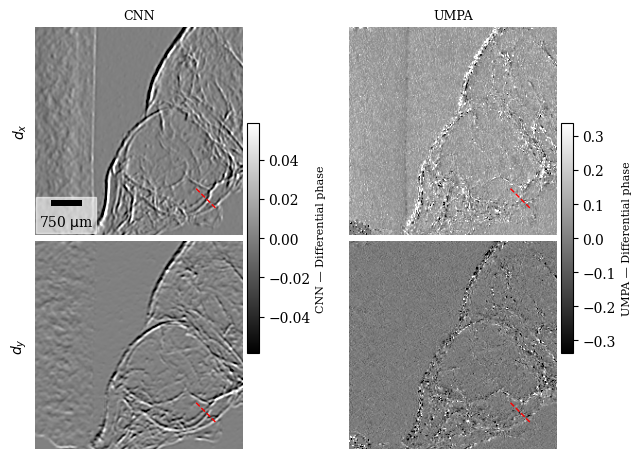

Factor de reescalado UMPA->CNN: dx=0.1998, dy=0.2964


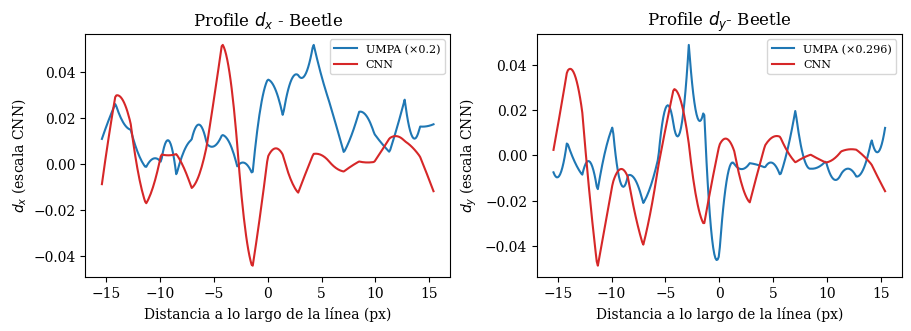

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
from scipy.ndimage import map_coordinates

plt.rcParams['font.family'] = 'serif'

# ---------------------------------------------------------------
# CARGA DE DATOS
# ---------------------------------------------------------------
folder_names = ["CNN_Cucarron", "UMPA_Cucarron"]
input_folder = "/home/c.tibambre/FS_Study/"
dx_name = "dx.txt"
dy_name = "dy.txt"
column_titles = ["CNN", "UMPA"]

dx_images = []
dy_images = []

for folder in folder_names:
    dx = np.loadtxt(input_folder + folder + "/" + dx_name)
    dy = np.loadtxt(input_folder + folder + "/" + dy_name)
    print(f"[{folder}] dx shape={dx.shape}, dy shape={dy.shape}, "
          f"dx min/max=({dx.min():.4g},{dx.max():.4g}), "
          f"dy min/max=({dy.min():.4g},{dy.max():.4g})")

    is_cnn = "CNN" in folder  # la CNN no se multiplica por -1 (convención de signo)
    if not is_cnn:
        dx = dx #* -1
        dy = dy * -1

    dx_images.append(dx)
    dy_images.append(dy)

# ---------------------------------------------------------------
# CROP (mismo que tu versión: mantiene el perfil dentro de la imagen)
# ---------------------------------------------------------------
crop_slice = (slice(15, 235), slice(15, 235))

dx_images = [img[crop_slice] for img in dx_images]
dy_images = [img[crop_slice] for img in dy_images]

dx_cnn, dx_umpa = dx_images
dy_cnn, dy_umpa = dy_images

# ---------------------------------------------------------------
# VMIN/VMAX SEPARADO POR MÉTODO (CNN y UMPA no están en la misma escala)
# ---------------------------------------------------------------
cnn_vals = np.concatenate([dx_cnn.ravel(), dy_cnn.ravel()])
umpa_vals = np.concatenate([dx_umpa.ravel(), dy_umpa.ravel()])

vmax_cnn = np.percentile(np.abs(cnn_vals), 99)
vmax_umpa = np.percentile(np.abs(umpa_vals), 99)
vmin_cnn, vmin_umpa = -vmax_cnn, -vmax_umpa

for name, v in zip(["CNN", "UMPA"], [vmax_cnn, vmax_umpa]):
    if v == 0 or not np.isfinite(v):
        raise ValueError(f"vmax calculado para {name} = {v}. Revisa la carga de datos.")

print(f"CNN  vmin/vmax = {vmin_cnn:.4g}/{vmax_cnn:.4g}")
print(f"UMPA vmin/vmax = {vmin_umpa:.4g}/{vmax_umpa:.4g}")


# ---------------------------------------------------------------
# FUNCIONES DE PERFIL EN DIRECCIÓN ARBITRARIA
# ---------------------------------------------------------------
def compute_line_coords(center, angle_deg, length, num_points=300):
    row_c, col_c = center
    theta = np.deg2rad(angle_deg)
    distances = np.linspace(-length / 2, length / 2, num_points)
    x_coords = col_c + distances * np.cos(theta)
    y_coords = row_c - distances * np.sin(theta)  # fila crece hacia abajo
    p0 = (x_coords[0], y_coords[0])
    p1 = (x_coords[-1], y_coords[-1])
    return distances, x_coords, y_coords, p0, p1


def sample_profile(img, x_coords, y_coords):
    return map_coordinates(img, [y_coords, x_coords], order=1, mode='nearest')


# --- Mismo center/angle/length que tu versión que funciona bien ---
img_ref = dx_cnn  # referencia solo para el tamaño (todas ya están recortadas igual)
center = (180, 180)
angle_deg = 135
length = min(img_ref.shape) * 0.14

distances, x_coords, y_coords, p0, p1 = compute_line_coords(center, angle_deg, length)

profile_dx_cnn  = sample_profile(dx_cnn,  x_coords, y_coords)
profile_dx_umpa = sample_profile(dx_umpa, x_coords, y_coords)
profile_dy_cnn  = sample_profile(dy_cnn,  x_coords, y_coords)
profile_dy_umpa = sample_profile(dy_umpa, x_coords, y_coords)

# ---------------------------------------------------------------
# GRAFICA: grid 2x2, línea de perfil en las 4 imágenes,
# colorbar separado para CNN (columna 0) y UMPA (columna 1)
# ---------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(6.2, 4.4), constrained_layout=True)
fig.get_layout_engine().set(w_pad=0.0, h_pad=0.0, wspace=0.0, hspace=0.03)

images_grid = [[dx_cnn, dx_umpa], [dy_cnn, dy_umpa]]
vmins = [vmin_cnn, vmin_umpa]
vmaxs = [vmax_cnn, vmax_umpa]

im_cnn_plot = None
im_umpa_plot = None

for row in range(2):
    for col in range(2):
        ax = axes[row, col]
        im = ax.imshow(images_grid[row][col], cmap='gray',
                        vmin=vmins[col], vmax=vmaxs[col])
        if col == 0:
            im_cnn_plot = im
        else:
            im_umpa_plot = im

        ax.plot([p0[0], p1[0]], [p0[1], p1[1]], color='red',
                linestyle='--', linewidth=1)

        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        for spine in ax.spines.values():
            spine.set_visible(False)

        if row == 0:
            ax.set_title(column_titles[col], fontsize=9)

axes[0, 0].set_ylabel(r'$d_{x}$', fontsize=10)
axes[1, 0].set_ylabel(r'$d_{y}$', fontsize=10)

scalebar = ScaleBar(
    22.5, "um", color="black", location="lower left",
    box_alpha=0.6, scale_loc="bottom", width_fraction=0.03
)
axes[0, 0].add_artist(scalebar)

# --- Dos colorbars separados: CNN y UMPA ---
cbar_cnn = fig.colorbar(im_cnn_plot, ax=axes[:, 0], orientation="vertical",
                         fraction=0.05, pad=0.02)
cbar_cnn.set_label("CNN — Differential phase", fontsize=8)

cbar_umpa = fig.colorbar(im_umpa_plot, ax=axes[:, 1], orientation="vertical",
                          fraction=0.05, pad=0.02)
cbar_umpa.set_label("UMPA — Differential phase", fontsize=8)

plt.savefig("DiffPhase_Insecto_grid.pdf", dpi=300, bbox_inches='tight')
plt.savefig("DiffPhase_Insecto_grid.png", dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------------
# COMPARACIÓN DE PERFILES: UMPA reescalado respecto a CNN
# ---------------------------------------------------------------
# Normalización simple: factor = max(|CNN|) / max(|UMPA|), calculado sobre
# el perfil mismo. Así UMPA queda a la misma amplitud pico que CNN.
factor_dx = np.max(np.abs(profile_dx_cnn)) / np.max(np.abs(profile_dx_umpa))
factor_dy = np.max(np.abs(profile_dy_cnn)) / np.max(np.abs(profile_dy_umpa))

profile_dx_umpa_scaled = profile_dx_umpa * factor_dx
profile_dy_umpa_scaled = profile_dy_umpa * factor_dy

print(f"Factor de reescalado UMPA->CNN: dx={factor_dx:.4g}, dy={factor_dy:.4g}")

fig2, (ax_dx, ax_dy) = plt.subplots(1, 2, figsize=(9, 3.2), constrained_layout=True)

ax_dx.plot(distances, profile_dx_umpa_scaled, label=f"UMPA (×{factor_dx:.3g})",
           color='tab:blue')
ax_dx.plot(distances, profile_dx_cnn, label="CNN", color='tab:red')
ax_dx.set_xlabel("Distancia a lo largo de la línea (px)")
ax_dx.set_ylabel(r'$d_{x}$ (escala CNN)')
ax_dx.set_title(f"Profile $d_x$ - Beetle")
ax_dx.legend(fontsize=8)

ax_dy.plot(distances, profile_dy_umpa_scaled, label=f"UMPA (×{factor_dy:.3g})",
           color='tab:blue')
ax_dy.plot(distances, profile_dy_cnn, label="CNN", color='tab:red')
ax_dy.set_xlabel("Distancia a lo largo de la línea (px)")
ax_dy.set_ylabel(r'$d_{y}$ (escala CNN)')
ax_dy.set_title(f"Profile $d_y$- Beetle")
ax_dy.legend(fontsize=8)

plt.savefig("Perfiles_UMPA_vs_CNN.png", dpi=300, bbox_inches='tight')
plt.show()

[CNN_Cucarron] dx shape=(256, 256), dy shape=(256, 256), dx min/max=(-0.1422,0.1373), dy min/max=(-0.1523,0.143)
[UMPA_Cucarron] dx shape=(251, 251), dy shape=(251, 251), dx min/max=(-1.484,1.818), dy min/max=(-1.515,1.527)
CNN  vmin/vmax = -0.05867/0.05867
UMPA vmin/vmax = -0.338/0.338


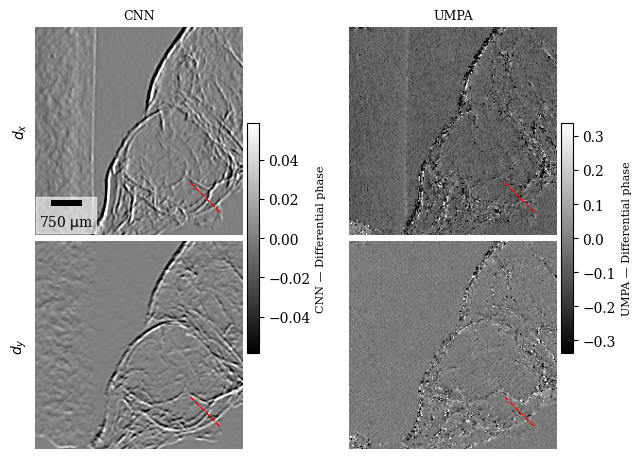

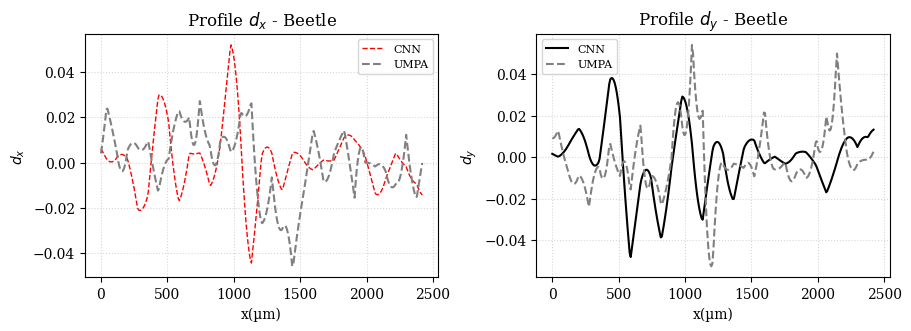

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
from scipy.ndimage import map_coordinates

plt.rcParams['font.family'] = 'serif'

# ---------------------------------------------------------------
# CARGA DE DATOS
# ---------------------------------------------------------------
folder_names = ["CNN_Cucarron", "UMPA_Cucarron"]
input_folder = "/home/c.tibambre/FS_Study/"
dx_name = "dx.txt"
dy_name = "dy.txt"
column_titles = ["CNN", "UMPA"]

dx_images = []
dy_images = []

for folder in folder_names:
    dx = np.loadtxt(input_folder + folder + "/" + dx_name)
    dy = np.loadtxt(input_folder + folder + "/" + dy_name)
    print(f"[{folder}] dx shape={dx.shape}, dy shape={dy.shape}, "
          f"dx min/max=({dx.min():.4g},{dx.max():.4g}), "
          f"dy min/max=({dy.min():.4g},{dy.max():.4g})")

    is_cnn = "CNN" in folder  # la CNN no se multiplica por -1 (convención de signo)
    if not is_cnn:
        dx = dx * -1
        dy = dy * -1

    dx_images.append(dx)
    dy_images.append(dy)

# ---------------------------------------------------------------
# CROP (mismo que tu versión: mantiene el perfil dentro de la imagen)
# ---------------------------------------------------------------
crop_slice = (slice(15, 235), slice(15, 235))

dx_images = [img[crop_slice] for img in dx_images]
dy_images = [img[crop_slice] for img in dy_images]

dx_cnn, dx_umpa = dx_images
dy_cnn, dy_umpa = dy_images

# ---------------------------------------------------------------
# VMIN/VMAX SEPARADO POR MÉTODO (CNN y UMPA no están en la misma escala)
# ---------------------------------------------------------------
cnn_vals = np.concatenate([dx_cnn.ravel(), dy_cnn.ravel()])
umpa_vals = np.concatenate([dx_umpa.ravel(), dy_umpa.ravel()])

vmax_cnn = np.percentile(np.abs(cnn_vals), 99)
vmax_umpa = np.percentile(np.abs(umpa_vals), 99)
vmin_cnn, vmin_umpa = -vmax_cnn, -vmax_umpa

for name, v in zip(["CNN", "UMPA"], [vmax_cnn, vmax_umpa]):
    if v == 0 or not np.isfinite(v):
        raise ValueError(f"vmax calculado para {name} = {v}. Revisa la carga de datos.")

print(f"CNN  vmin/vmax = {vmin_cnn:.4g}/{vmax_cnn:.4g}")
print(f"UMPA vmin/vmax = {vmin_umpa:.4g}/{vmax_umpa:.4g}")


# ---------------------------------------------------------------
# FUNCIONES DE PERFIL EN DIRECCIÓN ARBITRARIA
# ---------------------------------------------------------------
def compute_line_coords(center, angle_deg, length, num_points=300):
    row_c, col_c = center
    theta = np.deg2rad(angle_deg)
    distances = np.linspace(-length / 2, length / 2, num_points)
    x_coords = col_c + distances * np.cos(theta)
    y_coords = row_c - distances * np.sin(theta)  # fila crece hacia abajo
    p0 = (x_coords[0], y_coords[0])
    p1 = (x_coords[-1], y_coords[-1])
    return distances, x_coords, y_coords, p0, p1


def sample_profile(img, x_coords, y_coords):
    return map_coordinates(img, [y_coords, x_coords], order=1, mode='nearest')


# --- Mismo center/angle/length que tu versión que funciona bien ---
img_ref = dx_cnn  # referencia solo para el tamaño (todas ya están recortadas igual)
center = (180, 180)
angle_deg = 135
length = min(img_ref.shape) * 0.2

distances, x_coords, y_coords, p0, p1 = compute_line_coords(center, angle_deg, length)

profile_dx_cnn  = sample_profile(dx_cnn,  x_coords, y_coords)
profile_dx_umpa = sample_profile(dx_umpa, x_coords, y_coords)
profile_dy_cnn  = sample_profile(dy_cnn,  x_coords, y_coords)
profile_dy_umpa = sample_profile(dy_umpa, x_coords, y_coords)

# ---------------------------------------------------------------
# GRAFICA: grid 2x2, línea de perfil en las 4 imágenes,
# colorbar separado para CNN (columna 0) y UMPA (columna 1)
# ---------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(6.2, 4.4), constrained_layout=True)
fig.get_layout_engine().set(w_pad=0.0, h_pad=0.0, wspace=0.0, hspace=0.03)

images_grid = [[dx_cnn, dx_umpa], [dy_cnn, dy_umpa]]
vmins = [vmin_cnn, vmin_umpa]
vmaxs = [vmax_cnn, vmax_umpa]

im_cnn_plot = None
im_umpa_plot = None

for row in range(2):
    for col in range(2):
        ax = axes[row, col]
        im = ax.imshow(images_grid[row][col], cmap='gray',
                        vmin=vmins[col], vmax=vmaxs[col])
        if col == 0:
            im_cnn_plot = im
        else:
            im_umpa_plot = im

        ax.plot([p0[0], p1[0]], [p0[1], p1[1]], color='red',
                linestyle='--', linewidth=1)

        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        for spine in ax.spines.values():
            spine.set_visible(False)

        if row == 0:
            ax.set_title(column_titles[col], fontsize=9)

axes[0, 0].set_ylabel(r'$d_{x}$', fontsize=10)
axes[1, 0].set_ylabel(r'$d_{y}$', fontsize=10)

scalebar = ScaleBar(
    22.5, "um", color="black", location="lower left",
    box_alpha=0.6, scale_loc="bottom", width_fraction=0.03
)
axes[0, 0].add_artist(scalebar)

# --- Dos colorbars separados: CNN y UMPA ---
cbar_cnn = fig.colorbar(im_cnn_plot, ax=axes[:, 0], orientation="vertical",
                         fraction=0.05, pad=0.02)
cbar_cnn.set_label("CNN — Differential phase", fontsize=8)

cbar_umpa = fig.colorbar(im_umpa_plot, ax=axes[:, 1], orientation="vertical",
                          fraction=0.05, pad=0.02)
cbar_umpa.set_label("UMPA — Differential phase", fontsize=8)

plt.savefig("DiffPhase_Insecto_grid.pdf", dpi=300, bbox_inches='tight')
plt.savefig("DiffPhase_Insecto_grid.png", dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------------
# COMPARACIÓN DE PERFILES: UMPA ajustado a la escala de CNN
# ---------------------------------------------------------------
# En vez de solo escalar por el máximo (que ignora si hay un offset/nivel
# de base distinto entre métodos), igualamos media y desviación estándar:
# así UMPA queda centrado y escalado como CNN, lo que suele alinear mejor
# la forma de las dos curvas cuando difieren en offset además de amplitud.
def match_scale_offset(reference, target):
    ref_mean, ref_std = reference.mean(), reference.std()
    tgt_mean, tgt_std = target.mean(), target.std()
    if tgt_std == 0:
        return target
    return (target - tgt_mean) / tgt_std * ref_std + ref_mean


profile_dx_umpa_scaled = match_scale_offset(profile_dx_cnn, profile_dx_umpa)
profile_dy_umpa_scaled = match_scale_offset(profile_dy_cnn, profile_dy_umpa)

# --- Eje x en distancia física (µm), empezando en 0 en el extremo izquierdo ---
pixel_size_um = 55.0  # tamaño de pixel real
distances_um = (distances - distances[0]) * pixel_size_um

fig2, (ax_dx, ax_dy) = plt.subplots(1, 2, figsize=(9, 3.2), constrained_layout=True)

ax_dx.plot(distances_um, profile_dx_cnn, label="CNN", color='red',linestyle='--', linewidth=1)
ax_dx.plot(distances_um, profile_dx_umpa_scaled, label="UMPA",
           color='gray', linestyle='--')
ax_dx.set_xlabel("x(µm)")
ax_dx.set_ylabel(r'$d_{x}$')
ax_dx.set_title(f"Profile $d_x$ - Beetle")
ax_dx.grid(True, linestyle=':', alpha=0.5)
ax_dx.legend(fontsize=8)

ax_dy.plot(distances_um, profile_dy_cnn, label="CNN", color='black')
ax_dy.plot(distances_um, profile_dy_umpa_scaled, label="UMPA",
           color='gray', linestyle='--')
ax_dy.set_xlabel("x(µm)")
ax_dy.set_ylabel(r'$d_{y}$')
ax_dy.set_title(f"Profile $d_y$ - Beetle")
ax_dy.grid(True, linestyle=':', alpha=0.5)
ax_dy.legend(fontsize=8)

plt.savefig("Perfiles_UMPA_vs_CNN.png", dpi=300, bbox_inches='tight')
plt.show()

[CNN_Cucarron] dx shape=(256, 256), dy shape=(256, 256), dx min/max=(-0.1422,0.1373), dy min/max=(-0.1523,0.143)
[UMPA_Cucarron] dx shape=(251, 251), dy shape=(251, 251), dx min/max=(-1.484,1.818), dy min/max=(-1.515,1.527)
Margen recortado de CNN para alinear con UMPA: 2px por lado (asumiendo pérdida simétrica)
CNN  vmin/vmax = -0.05864/0.05864
UMPA vmin/vmax = -0.338/0.338


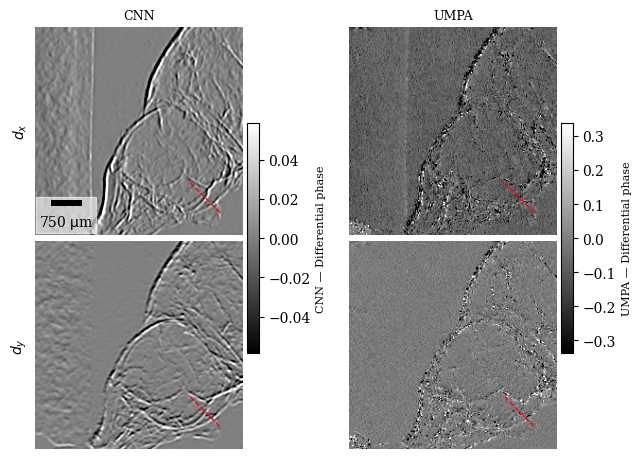

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
from scipy.ndimage import map_coordinates

plt.rcParams['font.family'] = 'serif'

# ---------------------------------------------------------------
# CARGA DE DATOS
# ---------------------------------------------------------------
folder_names = ["CNN_Cucarron", "UMPA_Cucarron"]
input_folder = "/home/c.tibambre/FS_Study/"
dx_name = "dx.txt"
dy_name = "dy.txt"
column_titles = ["CNN", "UMPA"]

dx_images = []
dy_images = []

for folder in folder_names:
    dx = np.loadtxt(input_folder + folder + "/" + dx_name)
    dy = np.loadtxt(input_folder + folder + "/" + dy_name)
    print(f"[{folder}] dx shape={dx.shape}, dy shape={dy.shape}, "
          f"dx min/max=({dx.min():.4g},{dx.max():.4g}), "
          f"dy min/max=({dy.min():.4g},{dy.max():.4g})")

    is_cnn = "CNN" in folder  # la CNN no se multiplica por -1 (convención de signo)
    if not is_cnn:
        dx = dx * -1
        dy = dy * -1

    dx_images.append(dx)
    dy_images.append(dy)

# ---------------------------------------------------------------
# ALINEAR ORIGEN ENTRE CNN (256x256) Y UMPA (251x251)
# ---------------------------------------------------------------
# UMPA pierde un borde porque su ventana deslizante (Nw) solo calcula donde
# la ventana completa cabe (recorte tipo 'valid'), así que su pixel (0,0)
# NO es el mismo punto físico que el pixel (0,0) de CNN. Si no corregimos
# esto, cualquier crop_slice compartido queda desalineado y los perfiles
# salen desplazados aunque el centro/ángulo/longitud sean idénticos.
# Asumimos pérdida de borde simétrica (típico en ventanas tipo 'valid'):
# recortamos el mismo margen también de CNN para igualar el origen físico.
def align_origin(img_big, img_small):
    h_big, w_big = img_big.shape
    h_small, w_small = img_small.shape
    margin_row = (h_big - h_small) // 2
    margin_col = (w_big - w_small) // 2
    return img_big[margin_row:margin_row + h_small, margin_col:margin_col + w_small]


dx_cnn_raw, dx_umpa_raw = dx_images
dy_cnn_raw, dy_umpa_raw = dy_images

assert dx_cnn_raw.shape[0] >= dx_umpa_raw.shape[0], \
    "Se esperaba que CNN fuera la imagen más grande; revisa el orden de folder_names."

dx_cnn_raw = align_origin(dx_cnn_raw, dx_umpa_raw)
dy_cnn_raw = align_origin(dy_cnn_raw, dy_umpa_raw)

print(f"Margen recortado de CNN para alinear con UMPA: "
      f"{(256 - dx_umpa_raw.shape[0]) // 2}px por lado (asumiendo pérdida simétrica)")

dx_images = [dx_cnn_raw, dx_umpa_raw]
dy_images = [dy_cnn_raw, dy_umpa_raw]

# ---------------------------------------------------------------
# CROP (mismo que tu versión: mantiene el perfil dentro de la imagen)
# ---------------------------------------------------------------
crop_slice = (slice(15, 235), slice(15, 235))

dx_images = [img[crop_slice] for img in dx_images]
dy_images = [img[crop_slice] for img in dy_images]

dx_cnn, dx_umpa = dx_images
dy_cnn, dy_umpa = dy_images

# ---------------------------------------------------------------
# VMIN/VMAX SEPARADO POR MÉTODO (CNN y UMPA no están en la misma escala)
# ---------------------------------------------------------------
cnn_vals = np.concatenate([dx_cnn.ravel(), dy_cnn.ravel()])
umpa_vals = np.concatenate([dx_umpa.ravel(), dy_umpa.ravel()])

vmax_cnn = np.percentile(np.abs(cnn_vals), 99)
vmax_umpa = np.percentile(np.abs(umpa_vals), 99)
vmin_cnn, vmin_umpa = -vmax_cnn, -vmax_umpa

for name, v in zip(["CNN", "UMPA"], [vmax_cnn, vmax_umpa]):
    if v == 0 or not np.isfinite(v):
        raise ValueError(f"vmax calculado para {name} = {v}. Revisa la carga de datos.")

print(f"CNN  vmin/vmax = {vmin_cnn:.4g}/{vmax_cnn:.4g}")
print(f"UMPA vmin/vmax = {vmin_umpa:.4g}/{vmax_umpa:.4g}")


# ---------------------------------------------------------------
# FUNCIONES DE PERFIL EN DIRECCIÓN ARBITRARIA
# ---------------------------------------------------------------
def compute_line_coords(center, angle_deg, length, num_points=300):
    row_c, col_c = center
    theta = np.deg2rad(angle_deg)
    distances = np.linspace(-length / 2, length / 2, num_points)
    x_coords = col_c + distances * np.cos(theta)
    y_coords = row_c - distances * np.sin(theta)  # fila crece hacia abajo
    p0 = (x_coords[0], y_coords[0])
    p1 = (x_coords[-1], y_coords[-1])
    return distances, x_coords, y_coords, p0, p1


def sample_profile(img, x_coords, y_coords):
    return map_coordinates(img, [y_coords, x_coords], order=1, mode='nearest')


# --- Mismo center/angle/length que tu versión que funciona bien ---
img_ref = dx_cnn  # referencia solo para el tamaño (todas ya están recortadas igual)
center = (180, 180)
angle_deg = 135
length = min(img_ref.shape) * 0.2

distances, x_coords, y_coords, p0, p1 = compute_line_coords(center, angle_deg, length)

profile_dx_cnn  = sample_profile(dx_cnn,  x_coords, y_coords)
profile_dx_umpa = sample_profile(dx_umpa, x_coords, y_coords)
profile_dy_cnn  = sample_profile(dy_cnn,  x_coords, y_coords)
profile_dy_umpa = sample_profile(dy_umpa, x_coords, y_coords)

# ---------------------------------------------------------------
# GRAFICA: grid 2x2, línea de perfil en las 4 imágenes,
# colorbar separado para CNN (columna 0) y UMPA (columna 1)
# ---------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(6.2, 4.4), constrained_layout=True)
fig.get_layout_engine().set(w_pad=0.0, h_pad=0.0, wspace=0.0, hspace=0.03)

images_grid = [[dx_cnn, dx_umpa], [dy_cnn, dy_umpa]]
vmins = [vmin_cnn, vmin_umpa]
vmaxs = [vmax_cnn, vmax_umpa]

im_cnn_plot = None
im_umpa_plot = None

for row in range(2):
    for col in range(2):
        ax = axes[row, col]
        im = ax.imshow(images_grid[row][col], cmap='gray',
                        vmin=vmins[col], vmax=vmaxs[col])
        if col == 0:
            im_cnn_plot = im
        else:
            im_umpa_plot = im

        ax.plot([p0[0], p1[0]], [p0[1], p1[1]], color='red',
                linestyle='--', linewidth=1)

        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        for spine in ax.spines.values():
            spine.set_visible(False)

        if row == 0:
            ax.set_title(column_titles[col], fontsize=9)

axes[0, 0].set_ylabel(r'$d_{x}$', fontsize=10)
axes[1, 0].set_ylabel(r'$d_{y}$', fontsize=10)

scalebar = ScaleBar(
    22.5, "um", color="black", location="lower left",
    box_alpha=0.6, scale_loc="bottom", width_fraction=0.03
)
axes[0, 0].add_artist(scalebar)

# --- Dos colorbars separados: CNN y UMPA ---
cbar_cnn = fig.colorbar(im_cnn_plot, ax=axes[:, 0], orientation="vertical",
                         fraction=0.05, pad=0.02)
cbar_cnn.set_label("CNN — Differential phase", fontsize=8)

cbar_umpa = fig.colorbar(im_umpa_plot, ax=axes[:, 1], orientation="vertical",
                          fraction=0.05, pad=0.02)
cbar_umpa.set_label("UMPA — Differential phase", fontsize=8)

plt.savefig("DiffPhase_Insecto_grid.pdf", dpi=300, bbox_inches='tight')
plt.savefig("DiffPhase_Insecto_grid.png", dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------------
# COMPARACIÓN DE PERFILES: UMPA ajustado a la escala de CNN
# ---------------------------------------------------------------
# En vez de solo escalar por el máximo (que ignora si hay un offset/nivel
# de base distinto entre métodos), igualamos media y desviación estándar:
# así UMPA queda centrado y escalado como CNN, lo que suele alinear mejor
# la forma de las dos curvas cuando difieren en offset además de amplitud.
def match_scale_offset(reference, target):
    ref_mean, ref_std = reference.mean(), reference.std()
    tgt_mean, tgt_std = target.mean(), target.std()
    if tgt_std == 0:
        return target
    return (target - tgt_mean) / tgt_std * ref_std + ref_mean


profile_dx_umpa_scaled = match_scale_offset(profile_dx_cnn, profile_dx_umpa)
profile_dy_umpa_scaled = match_scale_offset(profile_dy_cnn, profile_dy_umpa)

# --- Eje x en distancia física (µm), empezando en 0 en el extremo izquierdo ---
pixel_size_um = 55.0  # tamaño de pixel real
distances_um = (distances - distances[0]) * pixel_size_um

fig2, (ax_dx, ax_dy) = plt.subplots(1, 2, figsize=(9, 3.2), constrained_layout=True)

ax_dx.plot(distances_um, profile_dx_cnn, label="CNN", color='red',linestyle='--', linewidth=1)
ax_dx.plot(distances_um, profile_dx_umpa_scaled, label="UMPA",
           color='gray', linestyle='--')
ax_dx.set_xlabel("x(µm)")
ax_dx.set_ylabel("Displacement (pixel)")
ax_dx.set_title(f"a) Profile $d_x$ - Beetle")
ax_dx.grid(True, linestyle=':', alpha=0.5)
ax_dx.legend(fontsize=8)

ax_dy.plot(distances_um, profile_dy_cnn, label="CNN", color='blue',linestyle='--', linewidth=1)
ax_dy.plot(distances_um, profile_dy_umpa_scaled, label="UMPA",
           color='gray', linestyle='--')
ax_dy.set_xlabel("x(µm)")
ax_dy.set_ylabel("Displacement (pixel)")
ax_dy.set_title(f"b) Profile $d_y$ - Beetle")
ax_dy.grid(True, linestyle=':', alpha=0.5)
ax_dy.legend(fontsize=8)

plt.savefig("Perfiles_UMPA_vs_CNN.png", dpi=300, bbox_inches='tight')
plt.show()